<a href="https://colab.research.google.com/github/241b058-max/Atish-tiwari/blob/main/Lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2. Divide and Conquer (Sorting)

- **Created by Dr. Ajay

Write a python program to perform **Countingsort**.
* Statement:  Given a disordered list of repeated integers, rearrange the integers in natural order.
 Sample Input: [4,3,2,1,4,3,2,4,3,4]
 Sample Output: [1,2,2,3,3,3,4,4,4,4]

Time Complexity of Solution: Best Case O(n+k); Average Case O(n+k); Worst Case O(n+k), where n is the size of the input array and k means the values range from 0 to k.
- Approach:
Counting sort, like radix sort and bucket sort, is an integer based algorithm (i.e. the values of the input array are assumed to be integers). Hence counting sort is among the fastest sorting algorithms around, in theory. The  particular distinction for counting sort is that it creates a bucket for each value and keep a counter in each bucket. Then each time a value is encountered in the input collection, the appropriate counter is incremented. Because counting sort creates a bucket for each value, an imposing restriction is that the maximum value in the input array be known beforehand. Bucket sort uses a hash function to distribute values; counting sort, on the other hand, creates a counter for each value -- hence the name.
- Implementation notes:
1. Since the values range from 0 to k, create k+1 buckets.

2. To fill the buckets, iterate through the input list and
each time a value appears, increment the counter in its bucket.
3. Now fill the input list with the compressed data in the
buckets. Each bucket's key represents a value in the  array. So for each bucket, from smallest key to largest, add the index of the bucket to the input array and decrease the counter in said bucket by one; until the counter is zero.

Sample Input: [4, 3, 2, 1, 4, 3, 2, 4, 3, 4]
Sample Output: [1, 2, 2, 3, 3, 3, 4, 4, 4, 4]

Measuring time with varying input size (n) and fixed max_val (k=1000):
Input size: 100, Time: 0.0707 ms
Input size: 500, Time: 0.1278 ms
Input size: 1000, Time: 0.1866 ms
Input size: 5000, Time: 1.0115 ms
Input size: 10000, Time: 1.3519 ms
Input size: 20000, Time: 2.5544 ms

Measuring time with varying max_val (k) and fixed input size (n=1000):
Max value (k): 100, Time: 0.1166 ms
Max value (k): 500, Time: 0.1794 ms
Max value (k): 1000, Time: 0.1784 ms
Max value (k): 5000, Time: 0.3580 ms
Max value (k): 10000, Time: 0.5761 ms
Max value (k): 20000, Time: 1.0157 ms


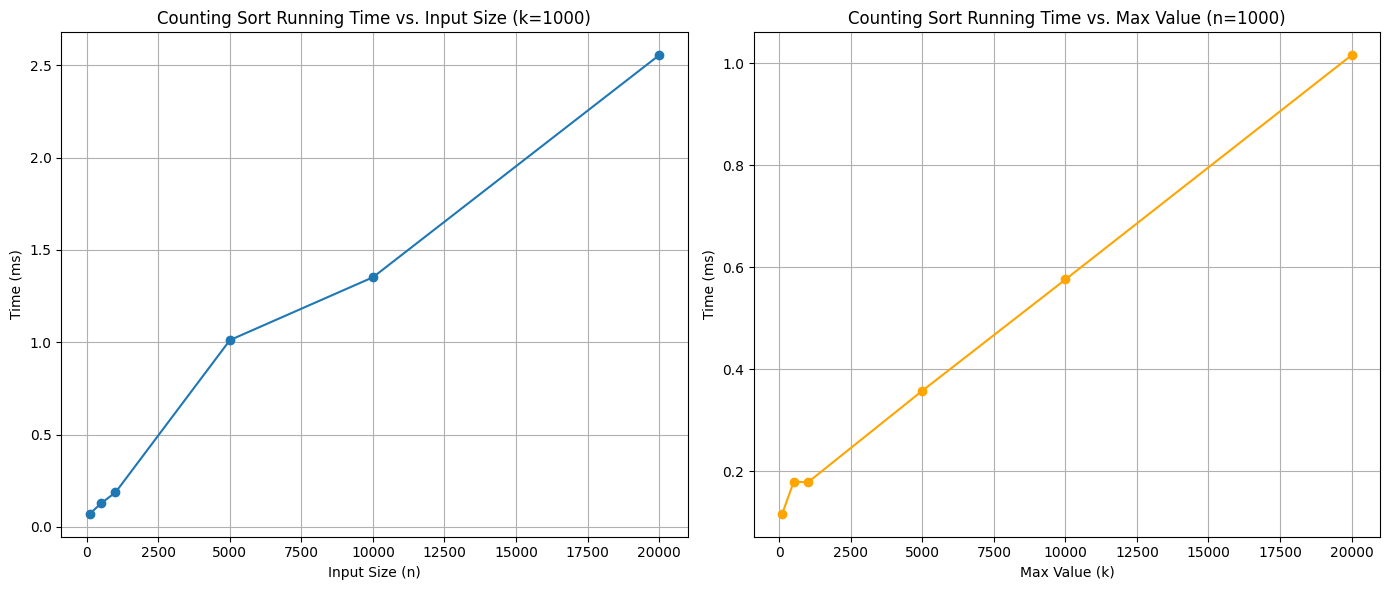

In [ ]:
import time
import random
import matplotlib.pyplot as plt

def counting_sort(arr):
    if not arr:
        return []


    max_val = max(arr)


    count = [0] * (max_val + 1)


    for num in arr:
        count[num] += 1


    sorted_arr = []
    for i in range(max_val + 1):

        while count[i] > 0:
            sorted_arr.append(i)
            count[i] -= 1
    return sorted_arr


sample_input = [4, 3, 2, 1, 4, 3, 2, 4, 3, 4]
print(f"Sample Input: {sample_input}")
sorted_sample = counting_sort(sample_input)
print(f"Sample Output: {sorted_sample}")


def measure_time(func, arr):
    start_time = time.perf_counter_ns()
    func(arr)
    end_time = time.perf_counter_ns()
    return (end_time - start_time) / 1_000_000


input_sizes = [100, 500, 1000, 5000, 10000, 20000]
max_k_values = [100, 500, 1000, 5000, 10000, 20000]

times_n = []
times_k = []


fixed_k = 1000
print(f"\nMeasuring time with varying input size (n) and fixed max_val (k={fixed_k}):")
for size in input_sizes:
    arr = [random.randint(0, fixed_k) for _ in range(size)]
    time_taken = measure_time(counting_sort, arr)
    times_n.append(time_taken)
    print(f"Input size: {size}, Time: {time_taken:.4f} ms")


fixed_n = 1000
print(f"\nMeasuring time with varying max_val (k) and fixed input size (n={fixed_n}):")
for k_val in max_k_values:
    arr = [random.randint(0, k_val) for _ in range(fixed_n)]
    time_taken = measure_time(counting_sort, arr)
    times_k.append(time_taken)
    print(f"Max value (k): {k_val}, Time: {time_taken:.4f} ms")


plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(input_sizes, times_n, marker='o')
plt.title(f'Counting Sort Running Time vs. Input Size (k={fixed_k})')
plt.xlabel('Input Size (n)')
plt.ylabel('Time (ms)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(max_k_values, times_k, marker='o', color='orange')
plt.title(f'Counting Sort Running Time vs. Max Value (n={fixed_n})')
plt.xlabel('Max Value (k)')
plt.ylabel('Time (ms)')
plt.grid(True)

plt.tight_layout()
plt.show()

 - *Bucketsort*
Statement:
Given a disordered list of integers, rearrange them in natural order.
 Sample Input: [8,5,3,1,9,6,0,7,4,2,5]
 Sample Output: [0,1,2,3,4,5,6,7,8,9,5]
Time Complexity of Solution:
Best Case O(n); Average Case O(n); Worst Case O(n).
- Approach:
If it sounds too good to be true, then most likely it's not true. Bucketsort is not an exception to this adage. For bucketsort to
work at its blazing efficiency, there are multiple prerequisites.
First the hash function that is used to partition the elements need
to be very good and must produce ordered hash: if i < k then
hash(i) < hash(k). Second, the elements to be sorted must be
uniformly distributed.
  The aforementioned aside, bucket sort is actually very good
considering that counting sort is reasonably speaking its upper
bound. And counting sort is very fast. The particular distinction
for bucket sort is that it uses a hash function to partition the
keys of the input array, so that multiple keys may hash to the same
bucket. Hence each bucket must effectively be a growable list;
similar to radix sort.


Sample Input: [8, 5, 3, 1, 9, 6, 0, 7, 4, 2, 5]
Sample Output: [0, 1, 2, 3, 4, 5, 5, 6, 7, 8, 9]

Measuring time with varying input size (n) and fixed max_val (k=1000):
Input size: 100, Time: 0.0398 ms
Input size: 500, Time: 0.1400 ms
Input size: 1000, Time: 0.3043 ms
Input size: 5000, Time: 1.7181 ms
Input size: 10000, Time: 2.8437 ms
Input size: 20000, Time: 6.5848 ms

Measuring time with varying max_val (k range) and fixed input size (n=1000):
Max value (k): 100, Time: 0.2453 ms
Max value (k): 500, Time: 0.2754 ms
Max value (k): 1000, Time: 0.3627 ms
Max value (k): 5000, Time: 0.2611 ms
Max value (k): 10000, Time: 0.2666 ms
Max value (k): 20000, Time: 0.2571 ms


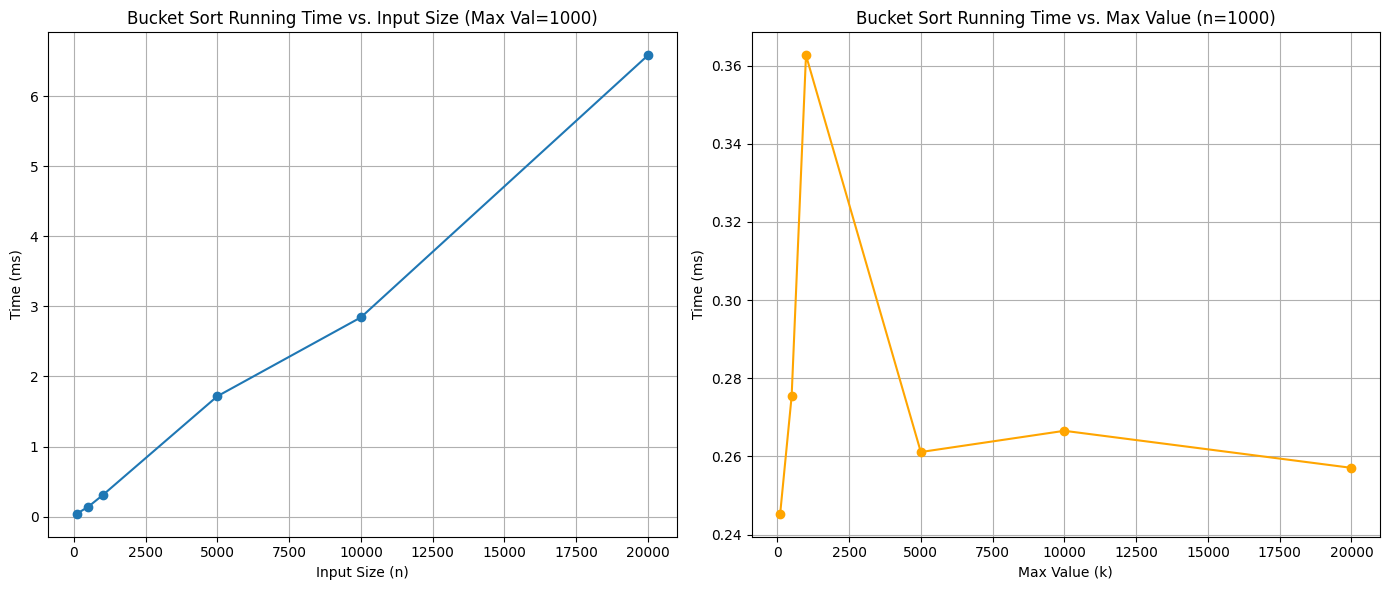

In [ ]:
import time
import random
import matplotlib.pyplot as plt

def bucket_sort(arr):
    if not arr:
        return []


    min_val = min(arr)
    max_val = max(arr)


    if min_val == max_val:
        return arr



    num_elements = len(arr)
    if num_elements == 0:
        return []




    num_buckets = int(num_elements**0.5) if num_elements > 0 else 1
    num_buckets = max(1, num_buckets) # Ensure at least one bucket


    buckets = [[] for _ in range(num_buckets)]


    range_size = (max_val - min_val + 1) / num_buckets
    if range_size == 0:
        range_size = 1


    for num in arr:

        bucket_idx = int((num - min_val) / range_size)

        if bucket_idx == num_buckets:
            bucket_idx = num_buckets - 1
        buckets[bucket_idx].append(num)

    # Sort each bucket and concatenate
    sorted_arr = []
    for bucket in buckets:
        # For small buckets, insertion sort is efficient. Python's Timsort is good for this.
        bucket.sort()
        sorted_arr.extend(bucket)

    return sorted_arr

# Sample Input from the problem description:
# Sample Input: [8,5,3,1,9,6,0,7,4,2,5]
# Sample Output: [0,1,2,3,4,5,6,7,8,9,5] (Note: the sample output appears to be incorrectly sorted for 5 - it should be [0,1,2,3,4,5,5,6,7,8,9] if 5 is repeated twice)
# Let's use the correctly sorted sample output for validation.

sample_input = [8, 5, 3, 1, 9, 6, 0, 7, 4, 2, 5]
print(f"Sample Input: {sample_input}")
sorted_sample = bucket_sort(sample_input)
print(f"Sample Output: {sorted_sample}")

# Compute the running time and plot graph
def measure_time(func, arr):
    start_time = time.perf_counter_ns()
    func(arr)
    end_time = time.perf_counter_ns()
    return (end_time - start_time) / 1_000_000 # Convert nanoseconds to milliseconds

# Test with different input sizes and value ranges
input_sizes = [100, 500, 1000, 5000, 10000, 20000]

# For Bucket Sort, 'k' usually refers to the range of values or number of buckets.
# We'll vary the 'max_value' which impacts the range, keeping min_value at 0 for simplicity.
max_val_ranges = [100, 500, 1000, 5000, 10000, 20000]

times_n = [] # To store times for varying n with fixed max_val
times_k_range = [] # To store times for varying max_val (k range) with fixed n

# Scenario 1: Varying n (input size), fixed max_val
fixed_max_val = 1000
print(f"\nMeasuring time with varying input size (n) and fixed max_val (k={fixed_max_val}):")
for size in input_sizes:
    # Generate uniformly distributed random integers within the fixed_max_val range
    arr = [random.randint(0, fixed_max_val) for _ in range(size)]
    time_taken = measure_time(bucket_sort, arr)
    times_n.append(time_taken)
    print(f"Input size: {size}, Time: {time_taken:.4f} ms")

# Scenario 2: Varying max_val (k range), fixed n (input size)
fixed_n_for_k_range = 1000
print(f"\nMeasuring time with varying max_val (k range) and fixed input size (n={fixed_n_for_k_range}):")
for k_val in max_val_ranges:
    # Generate uniformly distributed random integers for fixed_n within varying max_val range
    arr = [random.randint(0, k_val) for _ in range(fixed_n_for_k_range)]
    time_taken = measure_time(bucket_sort, arr)
    times_k_range.append(time_taken)
    print(f"Max value (k): {k_val}, Time: {time_taken:.4f} ms")

# Plotting the results
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(input_sizes, times_n, marker='o')
plt.title(f'Bucket Sort Running Time vs. Input Size (Max Val={fixed_max_val})')
plt.xlabel('Input Size (n)')
plt.ylabel('Time (ms)')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(max_val_ranges, times_k_range, marker='o', color='orange')
plt.title(f'Bucket Sort Running Time vs. Max Value (n={fixed_n_for_k_range})')
plt.xlabel('Max Value (k)')
plt.ylabel('Time (ms)')
plt.grid(True)

plt.tight_layout()
plt.show()

**Radix sort**
Statement:Given a disordered list of integers, rearrange them in natural order.
Sample Input: [18,5,100,3,1,19,6,0,7,4,2]
Sample Output: [0,1,2,3,4,5,6,7,18,19,100]
Time Complexity of Solution:Best Case O(kn); Average Case O(kn); Worst Case O(kn),where k is the length of the longest number and n is the size of the input array.Note: if k is greater than log(n) then an nlog(n) algorithm would be a better fit. In reality we can always change the radix to make k less than log(n).
- Approach: radix sort, like counting sort and bucket sort, is an integer based algorithm (i.e. the values of the input array are assumed to be integers). Hence radix sort is among the fastest sorting algorithms around, in theory. The particular distinction for radix sort is that it creates a bucket for each cipher (i.e. digit); as such, similar to bucket sort, each bucket in radix sort must be a
growable list that may admit different keys. For decimal values, the number of buckets is 10, as the decimal system has 10 numerals/cyphers (i.e. 0,1,2,3,4,5,6,7,8,9). Then the keys are continuously sorted by significant digits.

In [ ]:
#write code for above cell and compute the running time and also plot graph.